# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

We use GLMs/latent variable models/activation functions so that we can model non-continuous outcomes, hidden factors, or non-linear patterns. Linear models return a numeric value between negative and positive infinity, so they can't be restricted to probabilities between 0 and 1, categories, or whole number counts. Therefore, linear models are not always the correct model to use.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy are effective loss functions because they measure the difference between predicted and actual probability distributions, which aligns with the output of logistic regression. They heavily penalize confident, incorrect predictions, which improves the accuracy of the model.

3. True or false, and explain: Logistic regression is a linear model.

True (kind of). While logistic regression is not a simple linear model, it is considered a general linear model. Logistic regression calculates of a weighted sum of the parameters, however afterwards it applies a nonlinear sigmoid function. Therefore, the input is linear but the output is nonlinear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is specifically designed for classification. It predicts the probability of a categorical outcome, and a threshold (such as 0.5) is applied to convert the probabilities to class labels.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

False. The coefficients do not reflect a linear slope because the effect on probability is nonlinear. Rather, they represent the change in log-odds of the outcome for a 1 unit increase in the feature.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Since logistic regression is still linear in its parameters, feature engineering is still very important. By creating transformations of the original features, such as polynomial or interaction terms, the model can capture more complex relationships between the inputs and the target variable.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better for binary/categorical outcomes, but linear regression is more appropriate for continuous outcomes or simple approximations. The context of the problem determines which model is a better fit.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [40]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [41]:
df=df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [42]:
df.isna().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


There are no missing values.

In [43]:
df['is_dropout'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,is_dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [44]:
df['is_dropout'].value_counts()

,count
is_dropout,
0,3003
1,1421




2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?



In [45]:
from sklearn.linear_model import LogisticRegression
X=df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y=df['is_dropout']
model=LogisticRegression(penalty=None)
model.fit(X, y)
for feature, coef in zip(X.columns, model.coef_[0]):
  print(f'{feature}: {coef}')

Debtor: 0.5271372334701103
Tuition fees up to date: -2.6056171114201696
Scholarship holder: -1.24229888092226
Age at enrollment: 0.04984073793041426


The variables that increase dropout probability are debtor and age at enrollment, while tuition fees up to date and scholarship holder decrease dropout probability.

Yes, being up to date on tuition is associated with a lower probability of dropout.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?



In [46]:
df['predicted_dropout_prob'] = model.predict_proba(X)[:, 1]
df.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,is_dropout,predicted_dropout_prob
0,0,1,0,20,0,Dropout,1,0.254740
1,0,0,0,19,6,Graduate,0,0.814918
2,0,0,0,19,0,Dropout,1,0.814918
3,0,1,0,20,6,Graduate,0,0.254740
4,0,1,0,45,5,Graduate,0,0.543026


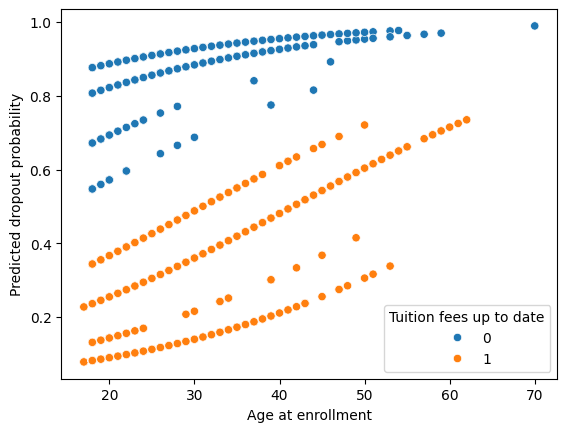

In [47]:
sns.scatterplot(data=df, x='Age at enrollment', y='predicted_dropout_prob', hue='Tuition fees up to date')
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.show()

In the older age range, around 40 to 50, being up to date on tution seems to reduce dropout probability the most. It is in that age range where the vertical separation between the two groups is the largest.

In [48]:
df.groupby('Tuition fees up to date')['predicted_dropout_prob'].mean()

,predicted_dropout_prob
Tuition fees up to date,
0,0.865533
1,0.247433


In [49]:
.865533-.247433

0.6181

On average, being up to date on tuition reduces the predicted probability of dropout from 0.87 to 0.25. Therefore, dropout probability decreases by approximately 0.62.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?



In [50]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X)
confusion_matrix(y, y_pred)

array([[2841,  162],
       [ 891,  530]])

The confusion matrix reveals that there were 2841 true negatives, 530 true positives, 891 false negatives, and 162 false positives.

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.7619801084990958

The overall accuracy of the model is approximately 0.76, meaning that the model correctly classifies about 76% of observations,.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.




In [52]:
from sklearn.linear_model import LinearRegression
X=df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y=df['predicted_dropout_prob']
lin_model=LinearRegression()
lin_model.fit(X, y)
df['predicted_dropout_prob_linear'] = lin_model.predict(X)
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,is_dropout,predicted_dropout_prob,predicted_dropout_prob_linear
0,0,1,0,20,0,Dropout,1,0.254740,0.263255
1,0,0,0,19,6,Graduate,0,0.814918,0.765943
2,0,0,0,19,0,Dropout,1,0.814918,0.765943
3,0,1,0,20,6,Graduate,0,0.254740,0.263255
4,0,1,0,45,5,Graduate,0,0.543026,0.500420


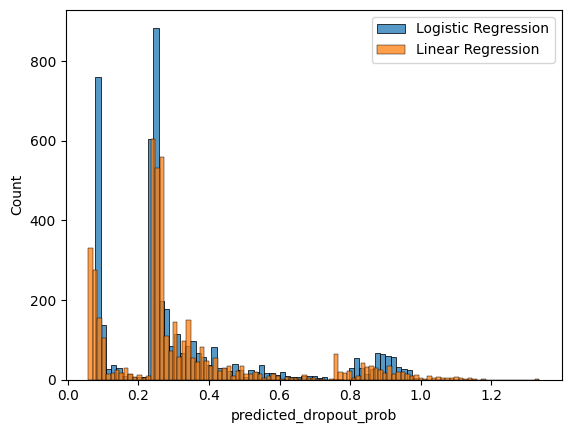

In [53]:
sns.histplot(data=df, x='predicted_dropout_prob', label='Logistic Regression')
sns.histplot(data=df, x='predicted_dropout_prob_linear', label='Linear Regression')
plt.legend()
plt.show()

The histogram shows that the predicted probabilities from logistic regression is bounded between 0 and 1, showing valid probabilities. The linear regression, however, produces probabilities greater than 1 and it is more spread out. Linear regression produces impossible probabilities and it is not designed for binary outcomes, so logistic regression provides more meaningful and interpretable predictions for this task.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?



The students that are most at risk for dropping out are students that are older, debtors, not up to date on tuition fees, and lack scholarships. In terms of interventions, increasing access to scholarships and financial aid would be effective for students struggling financially. There could also be targeted support for older students, such as mentoring or flexible scheduling, since they may have increased work and life responsibilities.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [54]:
model=LogisticRegression(multi_class='multinomial', max_iter=1000)
X=df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y=df['Target']
model.fit(X, y)
y_pred = model.predict(X)
confusion_matrix(y, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([[1054,    0,  367],
       [ 280,    0,  514],
       [ 146,    0, 2063]])

In [55]:
df['predicted_target'] = model.predict(X)
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,is_dropout,predicted_dropout_prob,predicted_dropout_prob_linear,predicted_target
0,0,1,0,20,0,Dropout,1,0.254740,0.263255,Dropout
1,0,0,0,19,6,Graduate,0,0.814918,0.765943,Dropout
2,0,0,0,19,0,Dropout,1,0.814918,0.765943,Dropout
3,0,1,0,20,6,Graduate,0,0.254740,0.263255,Graduate
4,0,1,0,45,5,Graduate,0,0.543026,0.500420,Graduate


In [56]:
model.classes_

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

The hard classification does not predict every class, because class 1 (enrolled) is never predicted. Rather, the model only predicts either dropout or graduate.

In [57]:
model.predict_proba(X)

array([[0.68054695, 0.21046429, 0.10898876],
       [0.69541412, 0.1460432 , 0.15854268],
       [0.95298821, 0.04119918, 0.00581261],
       ...,
       [0.07193813, 0.14064437, 0.78741751],
       [0.18422683, 0.21266883, 0.60310434],
       [0.11780804, 0.1769832 , 0.70520876]])

The predicted probabilities do include every class, regardless of whether they were ultimately selected in the hard classification.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [58]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [59]:
df=df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [60]:
df.isna().sum()

,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


In [61]:
df.dropna(inplace=True)
df.isna().sum()

,0
Bilirubin,0
Edema,0
Drug,0
Stage,0
Status,0


To handle missing values, I modified the dataframe by dropping all the rows with missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [62]:
df['Status']=df['Status'].apply(lambda x: 1 if x!='D' else 0)
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,0
1,1.1,N,D-penicillamine,3.0,1
2,1.4,S,D-penicillamine,4.0,0
3,1.8,S,D-penicillamine,4.0,0
4,3.4,N,Placebo,3.0,1


In [63]:
df['Drug'] = df['Drug'].apply(lambda x: 1 if x == 'D-penicillamine' else 0)
X_edema=pd.get_dummies(df['Edema'], drop_first=True)
X=pd.concat([df['Drug'], X_edema, df['Bilirubin']], axis=1)
y=df['Status']
model=LogisticRegression(penalty=None)
model.fit(X, y)
for feature, coef in zip(X.columns, model.coef_[0]):
  print(f'{feature}: {coef}')

Drug: -0.25282974710566114
S: -0.5782322705650635
Y: -2.8592199999103123
Bilirubin: -0.35038698959362896


The logistic regression shows that the drug actually decreases survival probability compared to the placebo. This could be because the patients that take the drug may have a worse case of cirrhosis to begin with. Additionally, a lower bilirubin predicts a higher survival rate. Edema that is solvable with diuretics slightly decreases one's probability of survival, and edema that prevails even with diuretics more drastically decreases this proabability.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

In [64]:
df['survival_prob']=model.predict_proba(X)[:,1]
df.head()

,Bilirubin,Edema,Drug,Stage,Status,survival_prob
0,14.5,Y,1,4.0,0,0.001455
1,1.1,N,1,3.0,1,0.735616
2,1.4,S,1,4.0,0,0.584180
3,1.8,S,1,4.0,0,0.549785
4,3.4,N,0,3.0,1,0.615442


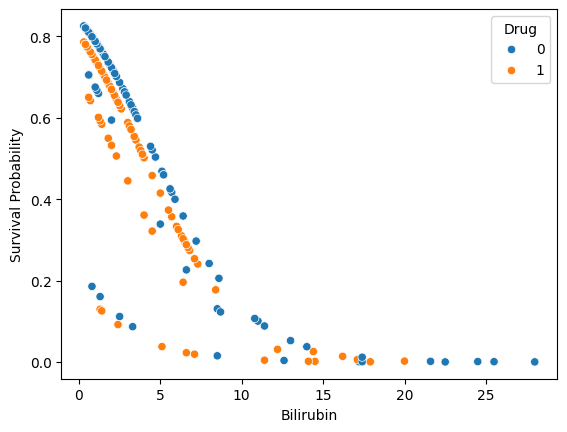

In [65]:
sns.scatterplot(data=df, x='Bilirubin', y='survival_prob', hue='Drug')
plt.xlabel('Bilirubin')
plt.ylabel('Survival Probability')
plt.show()

In [66]:
df.groupby('Drug')['survival_prob'].mean()

,survival_prob
Drug,
0,0.610411
1,0.588605


In [67]:
0.588605-0.610411

-0.021805999999999992

The scatter plot shows the predicted survival probability decreasing as bilirubin increases for both groups. Patients taking the drug generally have a lower survival probability, but it may slightly increase survival chances at higher levels of bilirubin, around 15 or 20. On average, patients receiving the drug have a survival probability that is 0.022 lower than those taking the placebo. This makes me question the effectiveness of the drug, and whether the decrease in survival probability is statistically significant or just due to chance.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [68]:
y_pred=model.predict(X)
confusion_matrix(y, y_pred)

array([[ 57,  68],
       [ 14, 173]])

In [69]:
accuracy_score(y, y_pred)

0.7371794871794872

The model has an accuracy of about 0.73, but the confusion matrix reveals that most of the errors come from false positives, where the model predicted survival when the patient actually died.









5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.



In [70]:
X=pd.concat([df['Drug'], X_edema, df['Bilirubin']], axis=1)
y=df['survival_prob']
lin_model=LinearRegression()
lin_model.fit(X, y)
df['survival_prob_linear']=lin_model.predict(X)
df.head()

,Bilirubin,Edema,Drug,Stage,Status,survival_prob,survival_prob_linear
0,14.5,Y,1,4.0,0,0.001455,-0.179857
1,1.1,N,1,3.0,1,0.735616,0.691973
2,1.4,S,1,4.0,0,0.584180,0.561381
3,1.8,S,1,4.0,0,0.549785,0.545754
4,3.4,N,0,3.0,1,0.615442,0.652779


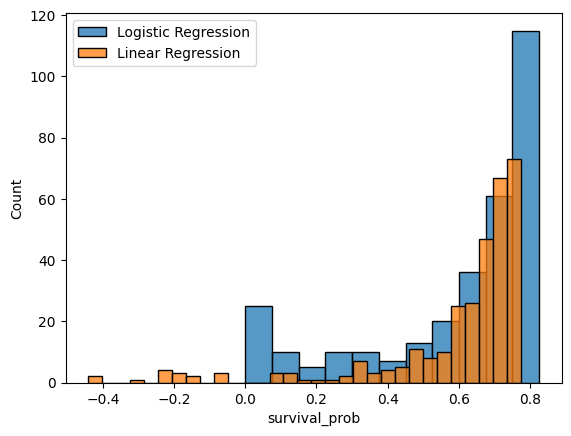

In [71]:
sns.histplot(data=df, x='survival_prob', label='Logistic Regression')
sns.histplot(data=df, x='survival_prob_linear', label='Linear Regression')
plt.legend()
plt.show()

Similar to what we saw before, the linear regression is not bounded between 0 and 1 so it contains invalid probabilities. There are probabilities as low as -0.4, which is a flaw in the linear model. However, we can also see that the logistic regression may be overconfident in predicting survival, represented by the cluster around high probabilities and the number of false positives in the confusion matrix. Despite this, logistic regression is still the better model because it is appropriate for binary classification and produces valid probabilistic outputs.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [72]:
X=pd.concat([X_edema, df['Bilirubin']], axis=1)
y=df['Stage']
model=LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)
df['predicted_stage']=model.predict(X)
df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Bilirubin,Edema,Drug,Stage,Status,survival_prob,survival_prob_linear,predicted_stage
0,14.5,Y,1,4.0,0,0.001455,-0.179857,4.0
1,1.1,N,1,3.0,1,0.735616,0.691973,3.0
2,1.4,S,1,4.0,0,0.584180,0.561381,3.0
3,1.8,S,1,4.0,0,0.549785,0.545754,4.0
4,3.4,N,0,3.0,1,0.615442,0.652779,3.0


In [73]:
y_pred=model.predict(X)
confusion_matrix(y, y_pred)

array([[  0,   0,  16,   0],
       [  0,   0,  63,   4],
       [  0,   0, 105,  15],
       [  0,   0,  79,  30]])

In [74]:
model.predict_proba(X)

array([[1.28550372e-05, 3.25351316e-02, 1.43611431e-01, 8.23840583e-01],
       [7.23937578e-02, 2.51555267e-01, 3.97519699e-01, 2.78531276e-01],
       [2.92626485e-02, 1.81530850e-01, 3.95694470e-01, 3.93512032e-01],
       ...,
       [5.23225350e-02, 2.46351600e-01, 4.07443845e-01, 2.93882020e-01],
       [4.43645995e-02, 2.43147794e-01, 4.11411355e-01, 3.01076251e-01],
       [3.56079503e-03, 1.81091914e-01, 4.27967363e-01, 3.87379928e-01]])

The hard classification does not predict every class, because it never predicts stage 1 or 2. The predicted probabilities, however, do predict every stage.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

In logistic regression, the coefficients represent how a one unit increase in a feature affects the log-odds of the outcome.

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?





3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

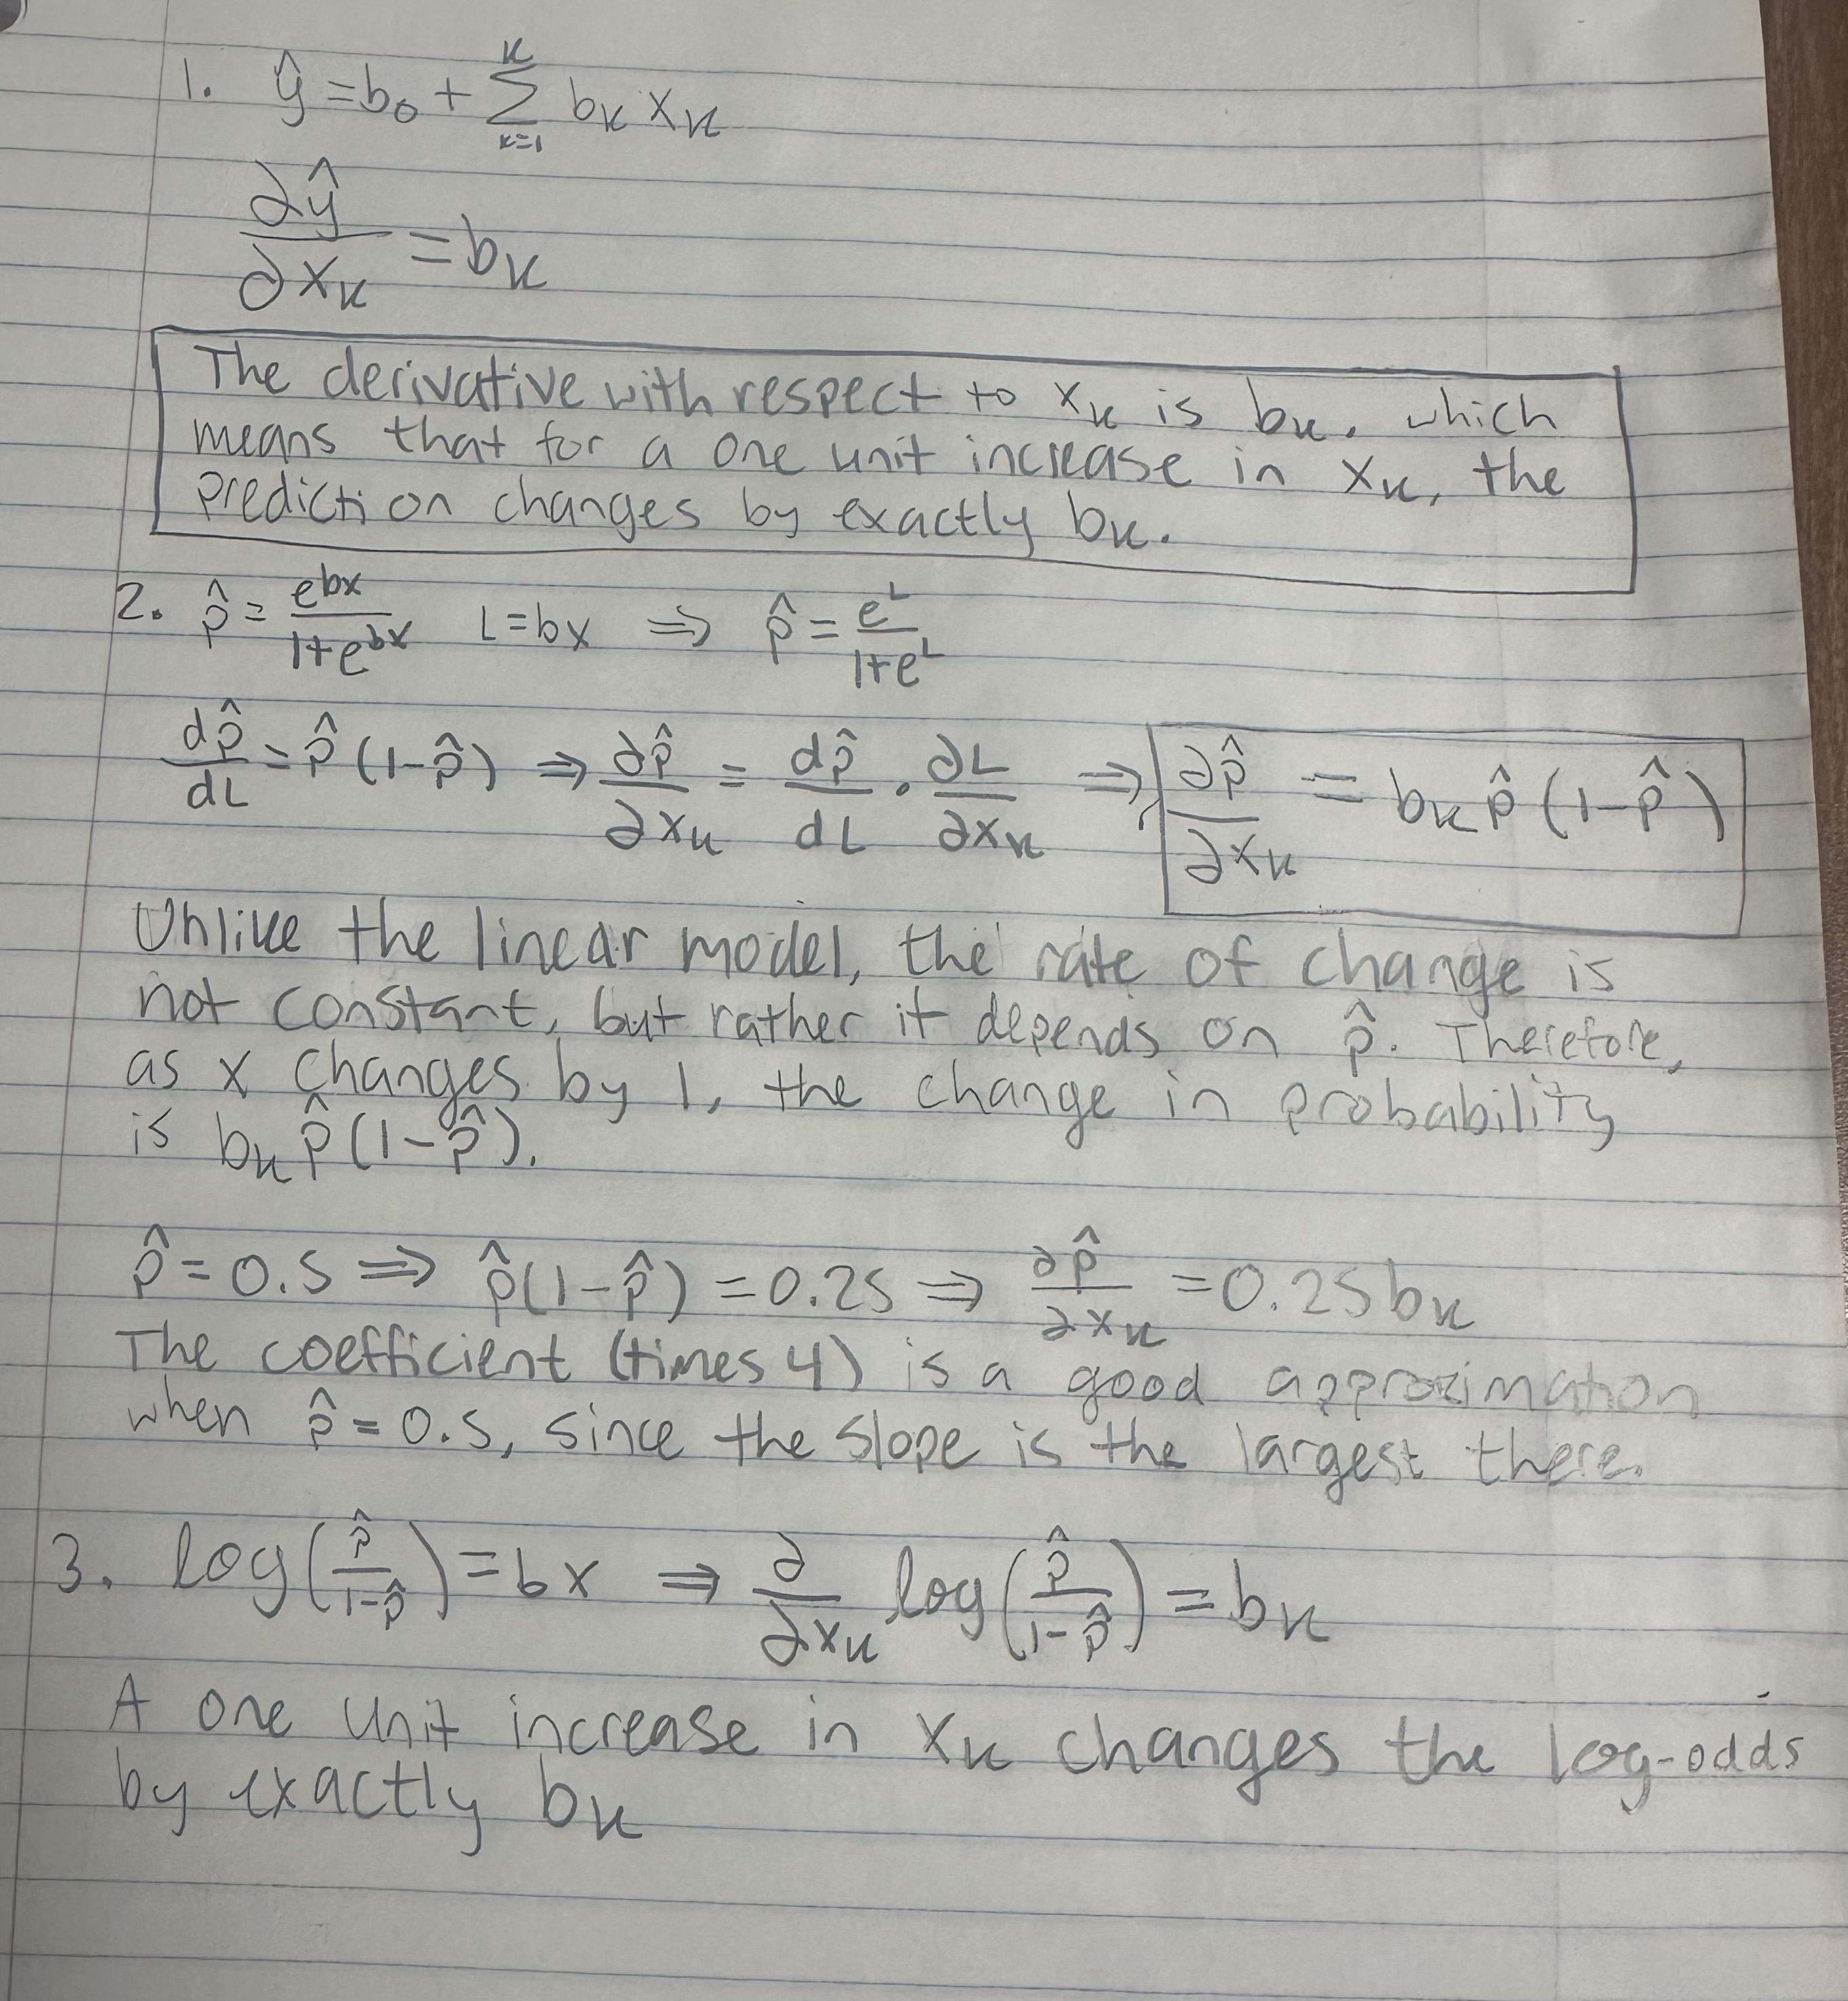